
# Módulo 2 - Regras Associativas
**Aluno:** Vinícius César Sena Torres  
**RA:** 22409225



## Objetivo
Extrair regras de coocorrência entre produtos líderes de venda para embasar promoções cruzadas seguindo a abordagem Apriori/FP-Growth.


In [1]:

# Organizo todas as bibliotecas que sustentam a etapa de regras e carrego a base de forma reprodutível.
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style='whitegrid', palette='muted')  # padroniza a estética para comparar gráficos entre módulos

DATA_PATH = Path('..') / 'walmart.csv'
df = pd.read_csv(DATA_PATH)  # dataset usado em toda a avaliação

print(f'Linhas: {df.shape[0]} | Usuários únicos: {df["User_ID"].nunique()}')
display(df.head())


Linhas: 550068 | Usuários únicos: 5891


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


Total de produtos distintos: 3631


,freq
Product_ID,
P00265242,1880
P00025442,1615
P00110742,1612
P00112142,1562
P00057642,1470
P00184942,1440
P00046742,1438
P00058042,1422
P00059442,1406


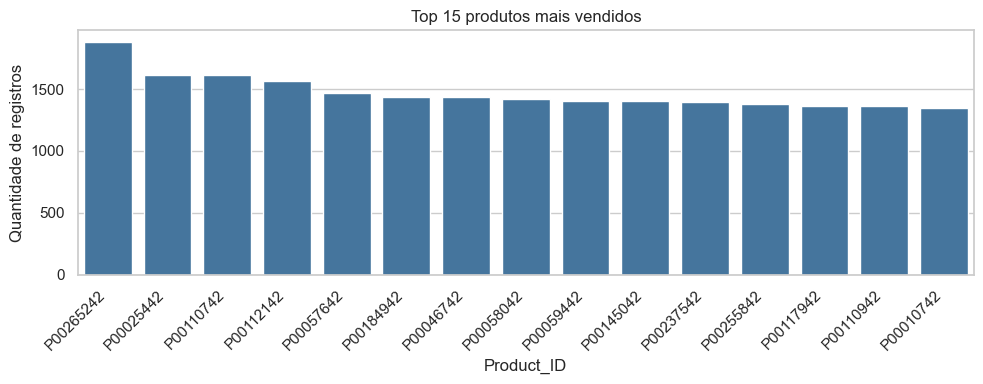

In [2]:

# Entendo a distribuição dos produtos para justificar o recorte nos itens mais vendidos.
product_freq = df['Product_ID'].value_counts()  # mede concentração da demanda por item
print('Total de produtos distintos:', product_freq.shape[0])
display(product_freq.head(10).to_frame(name='freq'))

plt.figure(figsize=(10, 4))
sns.barplot(  # visual revela cauda longa e reforça o corte em top-N
    x=product_freq.head(15).index,
    y=product_freq.head(15).values,
    color='#3776ab'
)
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 produtos mais vendidos')
plt.ylabel('Quantidade de registros')
plt.tight_layout()
plt.show()


In [3]:

# Converto o dataset para o formato cesta (presença/ausência) considerando apenas os top-N produtos.
TOP_N = 50  # quantidade mínima que garante suporte estatisticamente relevante
top_products = product_freq.head(TOP_N)
filtered = df[df['Product_ID'].isin(top_products.index)].copy()  # ignoro itens raros para reduzir ruído

transaction_matrix = (
    filtered
    .groupby(['User_ID', 'Product_ID'])
    .size()
    .unstack(fill_value=0)
)

transaction_matrix = (transaction_matrix > 0)  # booleano esperado pelo Apriori
transaction_counts = transaction_matrix.astype(int)  # redundância em int para calcular coocorrência via produto matricial
print('Matriz transacional:', transaction_matrix.shape)
transaction_matrix.head()


Matriz transacional: (5789, 50)


Product_ID,P00000142,P00003442,P00005042,P00010742,P00025442,P00028842,P00031042,P00034742,P00044442,P00046742,...,P00242742,P00251242,P00255842,P00258742,P00265242,P00270942,P00277642,P00278642,P00295942,P00334242
User_ID,,,,,,,,,,,,,,,,,,,,,
1000001,True,False,False,False,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,False
1000002,False,False,False,True,False,False,True,True,True,False,...,True,False,False,False,True,False,False,False,False,True
1000003,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,True,False,False
1000004,False,False,False,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1000005,False,True,False,False,False,False,True,False,False,False,...,False,True,True,False,True,False,True,False,False,False


In [4]:

# Rodo o Apriori com suporte mínimo de 3% para focar combinações relevantes.
frequent_itemsets = apriori(transaction_matrix, min_support=0.03, use_colnames=True)  # identifica grupos que aparecem em massa crítica
frequent_itemsets['length'] = frequent_itemsets['itemsets'].str.len()  # documenta o tamanho do conjunto para facilitar filtros

display(frequent_itemsets.sort_values('support', ascending=False).head(10))


,support,itemsets,length
44,0.324754,(P00265242),1
4,0.278977,(P00025442),1
21,0.278459,(P00110742),1
25,0.269822,(P00112142),1
12,0.253930,(P00057642),1
36,0.248748,(P00184942),1
9,0.248402,(P00046742),1
13,0.245638,(P00058042),1
14,0.242874,(P00059442),1
34,0.242874,(P00145042),1


In [5]:

# Traduzo as regras em métricas de suporte, confiança e lift para justificar ações de marketing.
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.05)  # garante relevância prática (lift > 1)
rules = rules[rules['confidence'] >= 0.3]  # remove associações frágeis
rules = rules.sort_values(by='lift', ascending=False)

def format_itemset(itemset):
    return ', '.join(sorted(itemset))  # ordeno para leitura amigável no relatório

rules['antecedentes'] = rules['antecedents'].apply(format_itemset)
rules['consequentes'] = rules['consequents'].apply(format_itemset)

display(rules[['antecedentes','consequentes','support','confidence','lift']].head(15))


,antecedentes,consequentes,support,confidence,lift
10644,"P00102642, P00112542",P00111142,0.031784,0.498645,2.843996
10524,"P00086442, P00112542",P00111142,0.031266,0.493188,2.812872
9622,"P00058042, P00080342",P00113242,0.030748,0.446115,2.768019
12030,"P00112542, P00145042",P00111142,0.033857,0.485149,2.767019
11982,"P00112142, P00112542",P00111142,0.037830,0.484513,2.763396
8670,"P00057642, P00073842",P00270942,0.037658,0.540943,2.718332
10475,"P00080342, P00112142",P00113242,0.030402,0.430318,2.670000
10523,"P00086442, P00111142",P00112542,0.031266,0.520115,2.662198
10409,"P00073842, P00114942",P00270942,0.032648,0.529412,2.660386
9024,"P00057642, P00112542",P00111142,0.037485,0.463675,2.644548


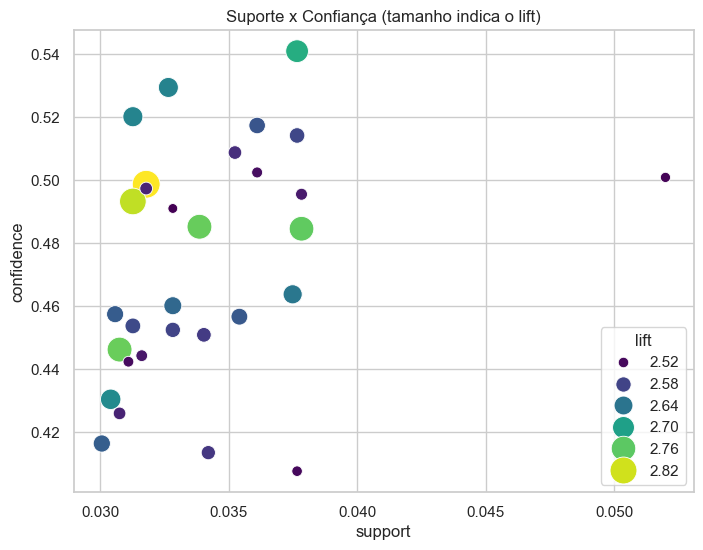

In [6]:

# Visualizo regras mais fortes para comunicar os achados.
top_rules_plot = rules.head(30)  # mantenho apenas as regras com maior lift para evitar poluição visual
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=top_rules_plot,
    x='support', y='confidence',
    size='lift', sizes=(50, 400),
    hue='lift', palette='viridis'
)
plt.title('Suporte x Confiança (tamanho indica o lift)')
plt.show()


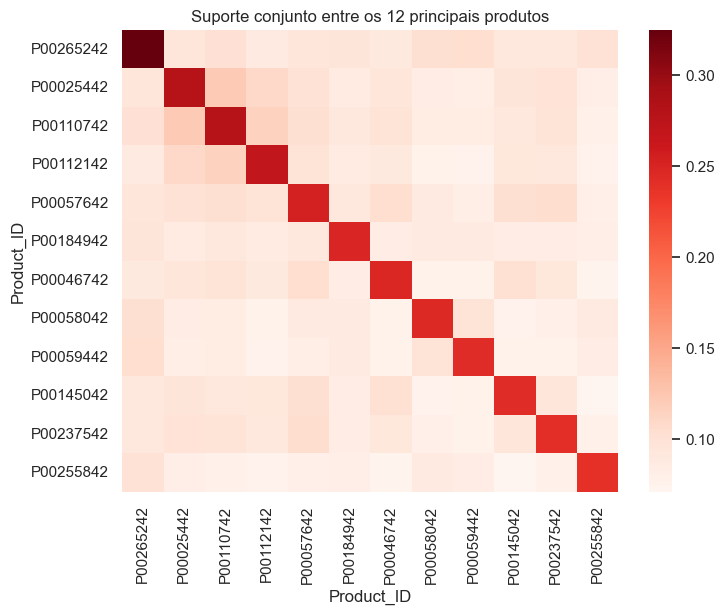

In [7]:

# Analiso coocorrências dos itens líderes para oferecer uma visão 2D.
top_for_heatmap = top_products.index[:12]  # limito para garantir legibilidade no mapa
co_matrix = transaction_counts[top_for_heatmap].T.dot(transaction_counts[top_for_heatmap])  # produto matricial conta co-compras
co_support = co_matrix / transaction_counts.shape[0]  # converto para suporte relativo

plt.figure(figsize=(8, 6))
sns.heatmap(co_support, cmap='Reds')
plt.title('Suporte conjunto entre os 12 principais produtos')
plt.show()


In [8]:

# Registro minhas interpretações para uso direto no relatório ABNT.
resumo_regras = []
for _, row in rules.head(5).iterrows():
    resumo_regras.append(
        f"{row['antecedentes']} => {row['consequentes']} | suporte {row['support']:.3f}, confiança {row['confidence']:.2f}, lift {row['lift']:.2f}"
    )

print('\n'.join(resumo_regras))


P00102642, P00112542 => P00111142 | suporte 0.032, confiança 0.50, lift 2.84
P00086442, P00112542 => P00111142 | suporte 0.031, confiança 0.49, lift 2.81
P00058042, P00080342 => P00113242 | suporte 0.031, confiança 0.45, lift 2.77
P00112542, P00145042 => P00111142 | suporte 0.034, confiança 0.49, lift 2.77
P00112142, P00112542 => P00111142 | suporte 0.038, confiança 0.48, lift 2.76



## Conclusões do módulo 2
* As regras com maior lift sugerem combos naturalizados pelos clientes, ótimos para sugestões automáticas e kits promocionais.
* Suporte acima de 3% indica relevância prática para campanhas, evitando insights com amostra pequena.
